# How are in-demand skills treanding for Data Analysts?

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import locale
import ast
locale.setlocale(locale.LC_TIME, 'en_US.UTF-8')  # Força locale para inglês

#Getting the data
df = pd.read_csv('data_jobs.csv')

#data cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills)

##### Grouping the Skills by Month

In this dataset the most popular country is the United States and the most popular job title is Data Analyst, so i'm gonna stick with that for my project!

In [16]:
# Skill count per month for data analysts
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].copy()
df_DA_US['job_posted_month_no'] = df_DA_US['job_posted_date'].dt.month

df_DA_US.sample(10)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month_no
115519,Data Analyst,Data Analyst,"San Luis Obispo, CA",via BeBee,Full-time,False,"California, United States",2023-11-27 08:00:47,False,True,United States,NaN,NaN,NaN,"City of San Luis Obispo, CA","[c, spreadsheet, terminal]","{'analyst_tools': ['spreadsheet'], 'other': ['...",11
96448,Data Analyst,Data Analyst,"Greenville, SC",via WayUp,Full-time,False,Georgia,2023-02-02 01:55:07,False,False,United States,NaN,NaN,NaN,BetterBuilt Storage,"[sql, power bi]","{'analyst_tools': ['power bi'], 'programming':...",2
121234,Data Analyst,Data Analyst,"Jefferson City, MO",via Monster,Part-time,False,"Illinois, United States",2023-01-24 08:02:38,False,True,United States,NaN,NaN,NaN,Ford Motor Company,"[r, python, sql, sas, sas, tableau, spss]","{'analyst_tools': ['sas', 'tableau', 'spss'], ...",1
501503,Data Analyst,Data Analyst,"Plano, TX",via Trabajo.org,Full-time,False,"Texas, United States",2023-07-13 11:01:02,True,False,United States,NaN,NaN,NaN,BCforward,"[tableau, excel, powerpoint]","{'analyst_tools': ['tableau', 'excel', 'powerp...",7
101322,Data Analyst,Sustainability Data Analyst - Climate Action,"Boston, MA",via ClimateTechList,Full-time,False,"New York, United States",2023-08-14 00:00:23,False,True,United States,NaN,NaN,NaN,ClimatePartner,[excel],{'analyst_tools': ['excel']},8
280734,Data Analyst,"Data Analyst, Supply Chain","Plano, TX",via MyArklaMiss Jobs,Full-time,False,"Texas, United States",2023-07-27 07:01:27,True,True,United States,NaN,NaN,NaN,Community Hospital Corporation,NaN,NaN,7
677113,Data Analyst,"Data Analyst, Paid Search","New York, NY",via Startup Jobs,Full-time,False,"New York, United States",2023-07-07 09:59:58,False,False,United States,NaN,NaN,NaN,Known,[excel],{'analyst_tools': ['excel']},7
368658,Data Analyst,Data Analyst,"New Britain, CT",via LinkedIn,Contractor,False,"New York, United States",2023-01-01 23:00:16,False,False,United States,NaN,NaN,NaN,"Metasys Technologies, Inc.","[sql, python, snowflake, visio, jira, confluence]","{'analyst_tools': ['visio'], 'async': ['jira',...",1
601827,Data Analyst,Data Analyst (Customer Relationship Management),"San Antonio, TX",via SimplyHired,Full-time,False,"Texas, United States",2023-08-23 09:01:32,True,False,United States,NaN,NaN,NaN,ENDEAVORS,NaN,NaN,8
253990,Data Analyst,Data Analyst,"Fort Mill, SC",via ZipRecruiter,Full-time,False,Georgia,2023-03-15 07:31:55,False,True,United States,NaN,NaN,NaN,FAST GROWING TREES LLC,"[sql, tableau]","{'analyst_tools': ['tableau'], 'programming': ...",3


##### Exploding skills and prepping for plotting

In [17]:
# Exploding job_skills column
df_DA_US_explode = df_DA_US.explode('job_skills')

#Pivot in Prep for Plotting
df_DA_US_pivot = df_DA_US_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc=('size'), fill_value=0)
df_DA_US_pivot.loc['Total'] = df_DA_US_pivot.sum()
df_DA_US_pivot = df_DA_US_pivot[df_DA_US_pivot.loc['Total'].sort_values(ascending=False).index] #Must put the index becausa it's a series, index makes it a df
df_DA_US_pivot.drop('Total',inplace=True)

df_DA_US_pivot.iloc[: , :5]

job_skills,sql,excel,tableau,python,sas
job_posted_month_no,,,,,
1,4601,3592,2488,2254,1832
2,3168,2587,1676,1618,1212
3,3226,2661,1804,1683,1238
4,3220,2549,1789,1679,1302
5,2581,2118,1432,1349,972
6,2862,2382,1628,1609,984
7,2609,2118,1533,1438,996
8,3414,2731,1951,2025,1276
9,2295,1801,1353,1229,856


##### Getting the percent for analysis

In [18]:
#Getting the total
DA_totals = df_DA_US.groupby('job_posted_month_no').size()

#Getting the percent
df_DA_US_perc = df_DA_US_pivot.div(DA_totals/100, axis=0) #Axis 0 is for the index and 1 is for the columns
df_DA_US_perc


job_skills,sql,excel,tableau,python,sas,r,power bi,word,powerpoint,oracle,...,capacitor,chainer,asp.net core,qt,microsoft lists,msaccess,kotlin,openstack,theano,xamarin
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,54.167648,42.288674,29.291264,26.536379,21.568166,17.812574,15.740523,11.396280,11.443372,8.453026,...,0.011773,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,51.730895,42.243632,27.367734,26.420640,19.790986,17.064010,18.321359,12.050947,11.512084,8.393207,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,51.881634,42.795111,29.012544,27.066581,19.909939,18.349952,16.950788,11.836603,10.759087,6.722419,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.016082
4,53.231939,42.139197,29.575136,27.756654,21.524219,17.159861,17.473963,11.489502,10.745578,7.257398,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,51.692369,42.419387,28.680152,27.017825,19.467254,17.364310,17.224114,11.155618,10.314440,7.170038,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.020028,0.000000,0.000000,0.000000,0.000000
6,50.360725,41.914482,28.646841,28.312511,17.314799,17.895478,17.402780,12.686961,10.980116,7.284885,...,0.000000,0.000000,0.000000,0.017596,0.000000,0.000000,0.017596,0.017596,0.000000,0.000000
7,50.163430,40.722938,29.475101,27.648529,19.150163,16.939050,16.939050,11.286291,10.555662,7.710056,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,51.462165,41.166717,29.409105,30.524570,19.234248,19.158879,18.209225,11.335544,11.245101,7.295749,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,49.471869,38.823022,29.165768,26.492779,18.452253,16.081052,17.676223,10.303945,10.239276,7.738737,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


##### Changing month number to month name

In [19]:
#changing months to names
t = df_DA_US_perc.reset_index()
t['job_posted_month'] = t['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
t = t.set_index('job_posted_month')
t = t.drop(columns='job_posted_month_no')

t

job_skills,sql,excel,tableau,python,sas,r,power bi,word,powerpoint,oracle,...,capacitor,chainer,asp.net core,qt,microsoft lists,msaccess,kotlin,openstack,theano,xamarin
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,54.167648,42.288674,29.291264,26.536379,21.568166,17.812574,15.740523,11.396280,11.443372,8.453026,...,0.011773,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Feb,51.730895,42.243632,27.367734,26.420640,19.790986,17.064010,18.321359,12.050947,11.512084,8.393207,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,51.881634,42.795111,29.012544,27.066581,19.909939,18.349952,16.950788,11.836603,10.759087,6.722419,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.016082
Apr,53.231939,42.139197,29.575136,27.756654,21.524219,17.159861,17.473963,11.489502,10.745578,7.257398,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
May,51.692369,42.419387,28.680152,27.017825,19.467254,17.364310,17.224114,11.155618,10.314440,7.170038,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.020028,0.000000,0.000000,0.000000,0.000000
Jun,50.360725,41.914482,28.646841,28.312511,17.314799,17.895478,17.402780,12.686961,10.980116,7.284885,...,0.000000,0.000000,0.000000,0.017596,0.000000,0.000000,0.017596,0.017596,0.000000,0.000000
Jul,50.163430,40.722938,29.475101,27.648529,19.150163,16.939050,16.939050,11.286291,10.555662,7.710056,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,51.462165,41.166717,29.409105,30.524570,19.234248,19.158879,18.209225,11.335544,11.245101,7.295749,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,49.471869,38.823022,29.165768,26.492779,18.452253,16.081052,17.676223,10.303945,10.239276,7.738737,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


### Plotting Monthly Skill Demand

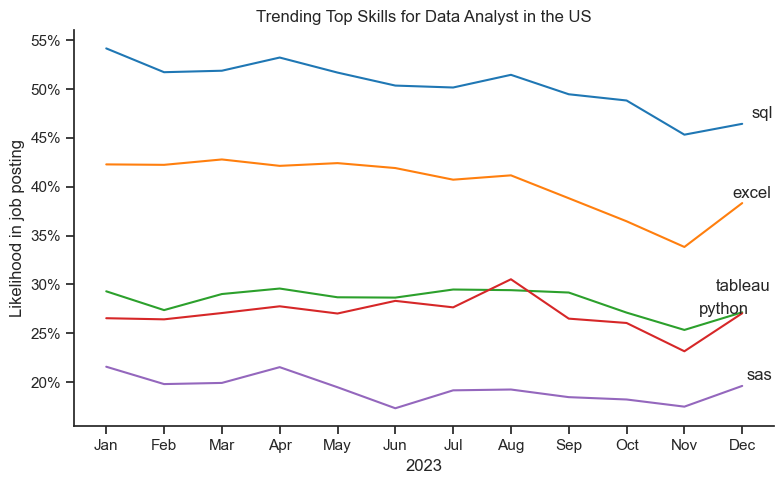

In [23]:
df_plot = t.iloc[: , :5]
plt.figure(figsize=(8,5))

from adjustText import adjust_text

sns.set_theme(style='ticks')
sns.lineplot(data=df_plot,
             dashes=False, #Makes the lines uniform
             palette='tab10',
             legend=False
             )
sns.despine()


from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

texts = []
for i in range(5):
    texts.append( #To ajust the text
            plt.text(11.2, # X position
             df_plot.iloc[-1, i], #-1 it's the last row, i it's the column
             df_plot.columns[i]
             )) 

adjust_text(texts, ax=ax,avoid_self=True)

plt.title('Trending Top Skills for Data Analyst in the US')
plt.ylabel('Likelihood in job posting')
plt.xlabel('2023')
plt.tight_layout()
plt.show()